In [ ]:
!pip install pandas numpy pillow tqdm


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

In [ ]:
pe = pd.read_csv("PE_Header.csv")
dll = pd.read_csv("DLLs_Imported.csv")
api = pd.read_csv("API_Functions.csv")
sec = pd.read_csv("PE_Section.csv")

In [ ]:
def preprocess(df):
    df = df.select_dtypes(include=[np.number])
    df = df.fillna(0)
    return df

pe = preprocess(pe)
dll = preprocess(dll)
api = preprocess(api)
sec = preprocess(sec)

In [ ]:
def normalize_row(row):
    row = row.astype(np.float32)

    if np.max(row) == np.min(row):
        return np.zeros_like(row)

    row = (row - np.min(row)) / (np.max(row) - np.min(row))
    row = (row * 255)

    return row.astype(np.uint8)

In [ ]:
def to_image(row, size=224):
    row = normalize_row(row)

    flat = row.flatten()

    if len(flat) < size*size:
        flat = np.pad(flat, (0, size*size - len(flat)))
    else:
        flat = flat[:size*size]

    return flat.reshape(size, size)

In [ ]:
output_path = "/content/output_layers"
os.makedirs(output_path, exist_ok=True)

num_samples = min(len(pe), len(dll), len(api), len(sec))

In [ ]:
output_path = "/content/demo"
os.makedirs(output_path, exist_ok=True)

num_samples = min(len(pe_header), len(dll), len(api), len(section))

for i in tqdm(range(2)):
    try:
        folder = os.path.join(output_path, f"sample_{i}")
        os.makedirs(folder, exist_ok=True)

        # Create each layer
        layer1 = to_image(pe.iloc[i].values)
        layer2 = to_image(dll.iloc[i].values)
        layer3 = to_image(api.iloc[i].values)
        layer4 = to_image(sec.iloc[i].values)

        # Save images
        Image.fromarray(layer1).save(os.path.join(folder, "layer1_pe.png"))
        Image.fromarray(layer2).save(os.path.join(folder, "layer2_dll.png"))
        Image.fromarray(layer3).save(os.path.join(folder, "layer3_api.png"))
        Image.fromarray(layer4).save(os.path.join(folder, "layer4_section.png"))

    except Exception as e:
        print(f"Error at {i}: {e}")

100%|██████████| 2/2 [00:00<00:00, 53.19it/s]


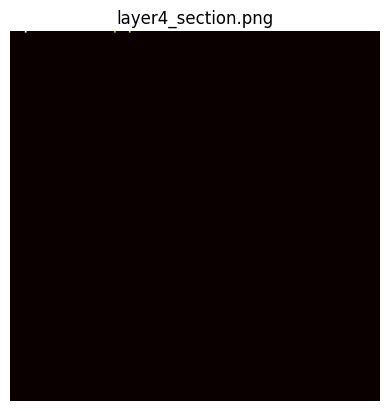

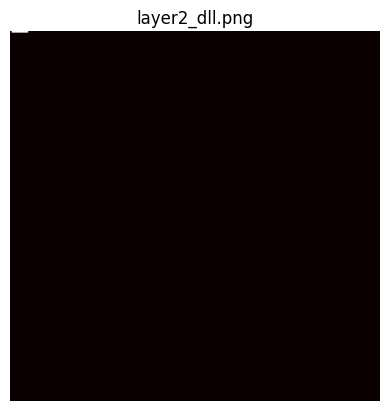

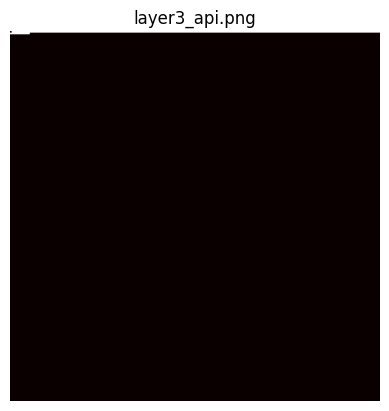

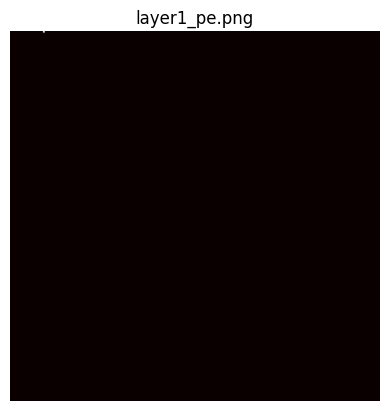

In [ ]:
import matplotlib.pyplot as plt

sample_folder = os.path.join(output_path, "sample_0")

for img_name in os.listdir(sample_folder):
    img = plt.imread(os.path.join(sample_folder, img_name))
    plt.imshow(img, cmap='hot')
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [ ]:
import os

# Ensure output_path is defined if running this cell independently
# If output_path is already defined in the kernel from a previous run, it will be used.
# If not, you might need to run the cell that defines output_path first (HjvZQkMcSTQX or HXZ8mB0mSVKn)
if 'output_path' not in locals() or output_path is None:
    output_path = "/content/malware_images"

# Zip the entire malware_images directory
!zip -r malware_layers.zip {output_path}

In [ ]:
from google.colab import files
files.download("malware_layers.zip")